Dataset Shape: (569, 30)

Target Classes: ['malignant' 'benign']

First 5 Rows:
   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520         0.2597   
4           0.13280          0.1980              0.10430         0.1809   

   mean frac

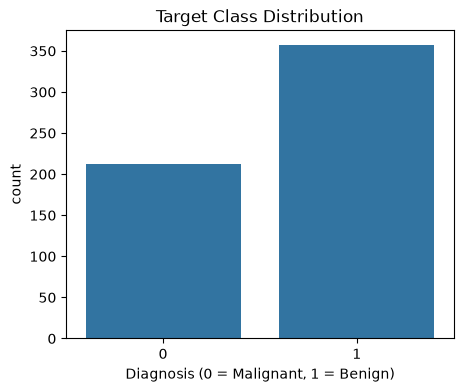

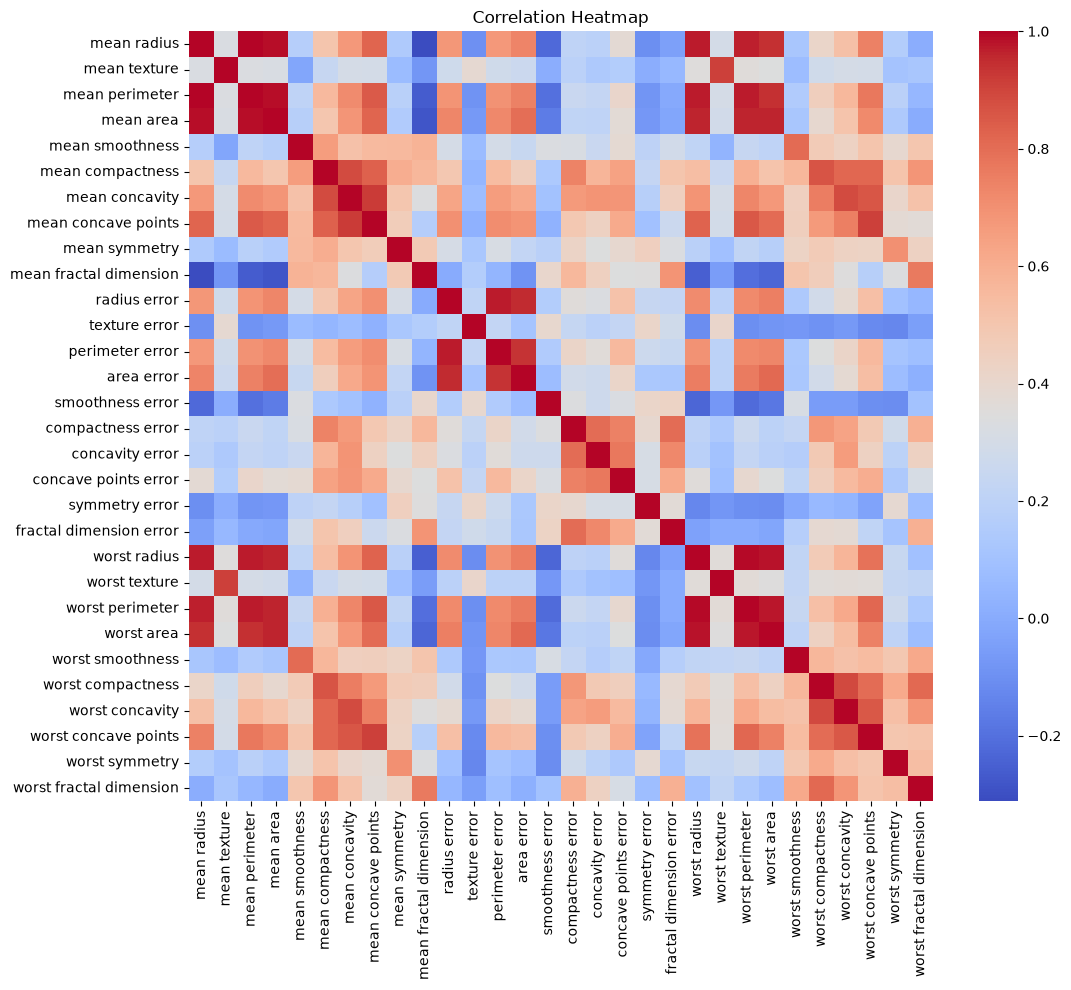


Training Samples: 455
Testing Samples: 114

Model Evaluation

Confusion Matrix:
[[39  3]
 [ 7 65]]

Accuracy : 0.9122807017543859
Precision : 0.9558823529411765
Recall    : 0.9027777777777778
F1 Score  : 0.9285714285714286

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.93      0.89        42
           1       0.96      0.90      0.93        72

    accuracy                           0.91       114
   macro avg       0.90      0.92      0.91       114
weighted avg       0.92      0.91      0.91       114



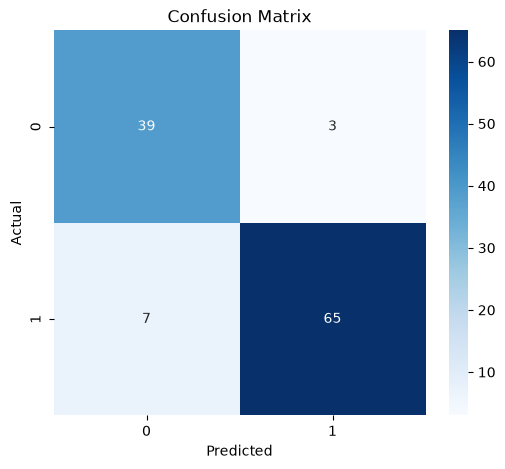


Best Parameters:
{'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 5}

Tuned Model Accuracy: 0.9210526315789473


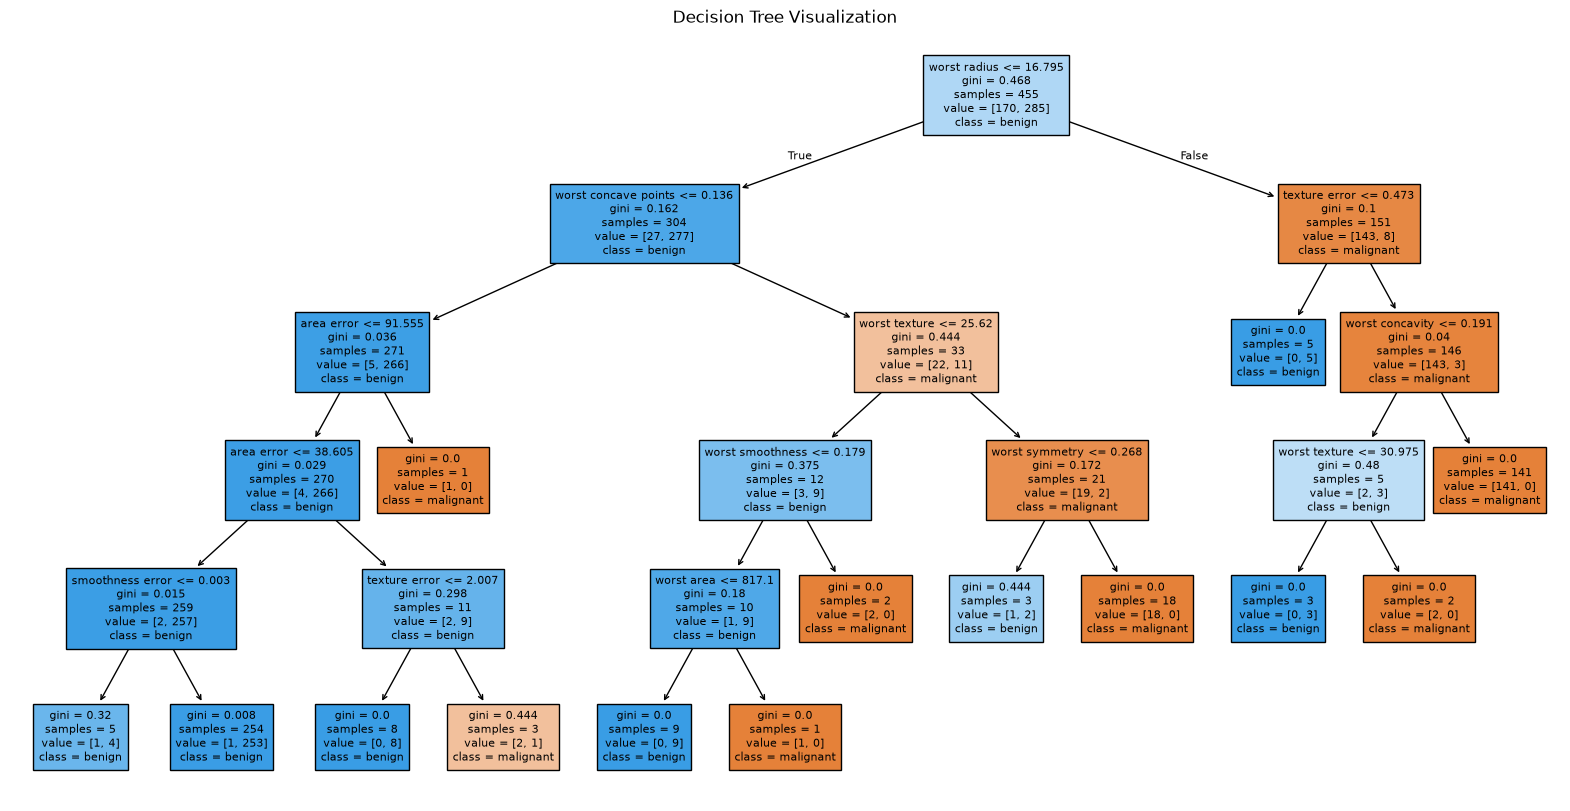

In [2]:
# ============================================================
# Binary Classification using Decision Tree with Gini Impurity
# ============================================================

# Step 1: Import Required Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Dataset
from sklearn.datasets import load_breast_cancer

# Model Selection
from sklearn.model_selection import train_test_split, GridSearchCV

# Decision Tree
from sklearn.tree import DecisionTreeClassifier, plot_tree

# Evaluation Metrics
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# ============================================================
# Step 2: Load Dataset
# ============================================================

data = load_breast_cancer()

X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target)

print("Dataset Shape:", X.shape)
print("\nTarget Classes:", data.target_names)

# ============================================================
# Step 3: Exploratory Data Analysis (EDA)
# ============================================================

print("\nFirst 5 Rows:")
print(X.head())

print("\nDataset Information:")
X.info()

print("\nStatistical Summary:")
print(X.describe())

print("\nMissing Values:")
print(X.isnull().sum())

# Target Distribution
plt.figure(figsize=(5, 4))
sns.countplot(x=y)
plt.title("Target Class Distribution")
plt.xlabel("Diagnosis (0 = Malignant, 1 = Benign)")
plt.show()

# Correlation Heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(X.corr(), cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

# ============================================================
# Step 4: Train-Test Split
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("\nTraining Samples:", X_train.shape[0])
print("Testing Samples:", X_test.shape[0])

# ============================================================
# Step 5: Train Decision Tree using Gini
# ============================================================

dt = DecisionTreeClassifier(
    criterion="gini",
    random_state=42
)

dt.fit(X_train, y_train)

# Predictions
y_pred = dt.predict(X_test)

# ============================================================
# Step 6: Model Evaluation
# ============================================================

print("\nModel Evaluation")

cm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix:")
print(cm)

print("\nAccuracy :", accuracy_score(y_test, y_pred))
print("Precision :", precision_score(y_test, y_pred))
print("Recall    :", recall_score(y_test, y_pred))
print("F1 Score  :", f1_score(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Confusion Matrix Visualization
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# ============================================================
# Step 7: Hyperparameter Tuning
# ============================================================

param_grid = {
    "max_depth": [3, 5, 7, 10, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

grid_search = GridSearchCV(
    DecisionTreeClassifier(
        criterion="gini",
        random_state=42
    ),
    param_grid=param_grid,
    cv=5,
    scoring="accuracy"
)

grid_search.fit(X_train, y_train)

print("\nBest Parameters:")
print(grid_search.best_params_)

best_model = grid_search.best_estimator_

# ============================================================
# Step 8: Evaluate Tuned Model
# ============================================================

y_pred_best = best_model.predict(X_test)

print("\nTuned Model Accuracy:",
      accuracy_score(y_test, y_pred_best))

# ============================================================
# Step 9: Visualize Decision Tree
# ============================================================

plt.figure(figsize=(20, 10))

plot_tree(
    best_model,
    feature_names=X.columns,
    class_names=data.target_names,
    filled=True,
    fontsize=8
)

plt.title("Decision Tree Visualization")
plt.show()